# Visualizzazione dei Risultati dell'Analisi del Sentiment

Questo notebook si occupa del caricamento del dataset con le predizioni del sentiment e della generazione dei grafici di andamento temporale e distribuzione degli score, mettendo a confronto il modello italiano-specifico e il modello multilingua.

### 1. Caricamento Dati

Carichiamo il dataset finale arricchito con le predizioni e gli score continui dei due modelli a confronto.

> **Nota di lavoro originale:** qui provare a plottare la time series e vedere come cambia il sentiment se ci sono dei picchi

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

DATASET_PATH = r"C:\dev\nlp\output\cardiffnlp_multilingua_v2.csv"


In [4]:
df = pd.read_csv(DATASET_PATH)

df.head()

print(df.count())

id                           13465
cid                          13465
created_at                   13465
indexed_at                   13465
text_raw                     13460
text_clean                   13453
hashtags                     13465
keyword_source               13465
author_did                   13465
author_handle                13465
author_display_name          10841
author_createdAt             13465
like_count                   13465
repost_count                 13465
reply_count                  13465
quote_count                  13465
bookmark_count               13465
viewer_like                      0
viewer_repost                    0
viewer_pinned                    0
viewer_bookmarked            13465
date                         13465
sent_multilingua_score       13465
sentiment_multilingua        13465
sent_italiano_score          13465
sentiment_italiano           13465
sent_multilingua_v2_score    13465
sentiment_multilingua_v2     13465
dtype: int64


### 2. Andamento Temporale del Sentiment Score

Normalizziamo la data dei post per isolare il giorno di pubblicazione, calcoliamo la media giornaliera degli score e tracciamo il grafico temporale comparativo dei due modelli.

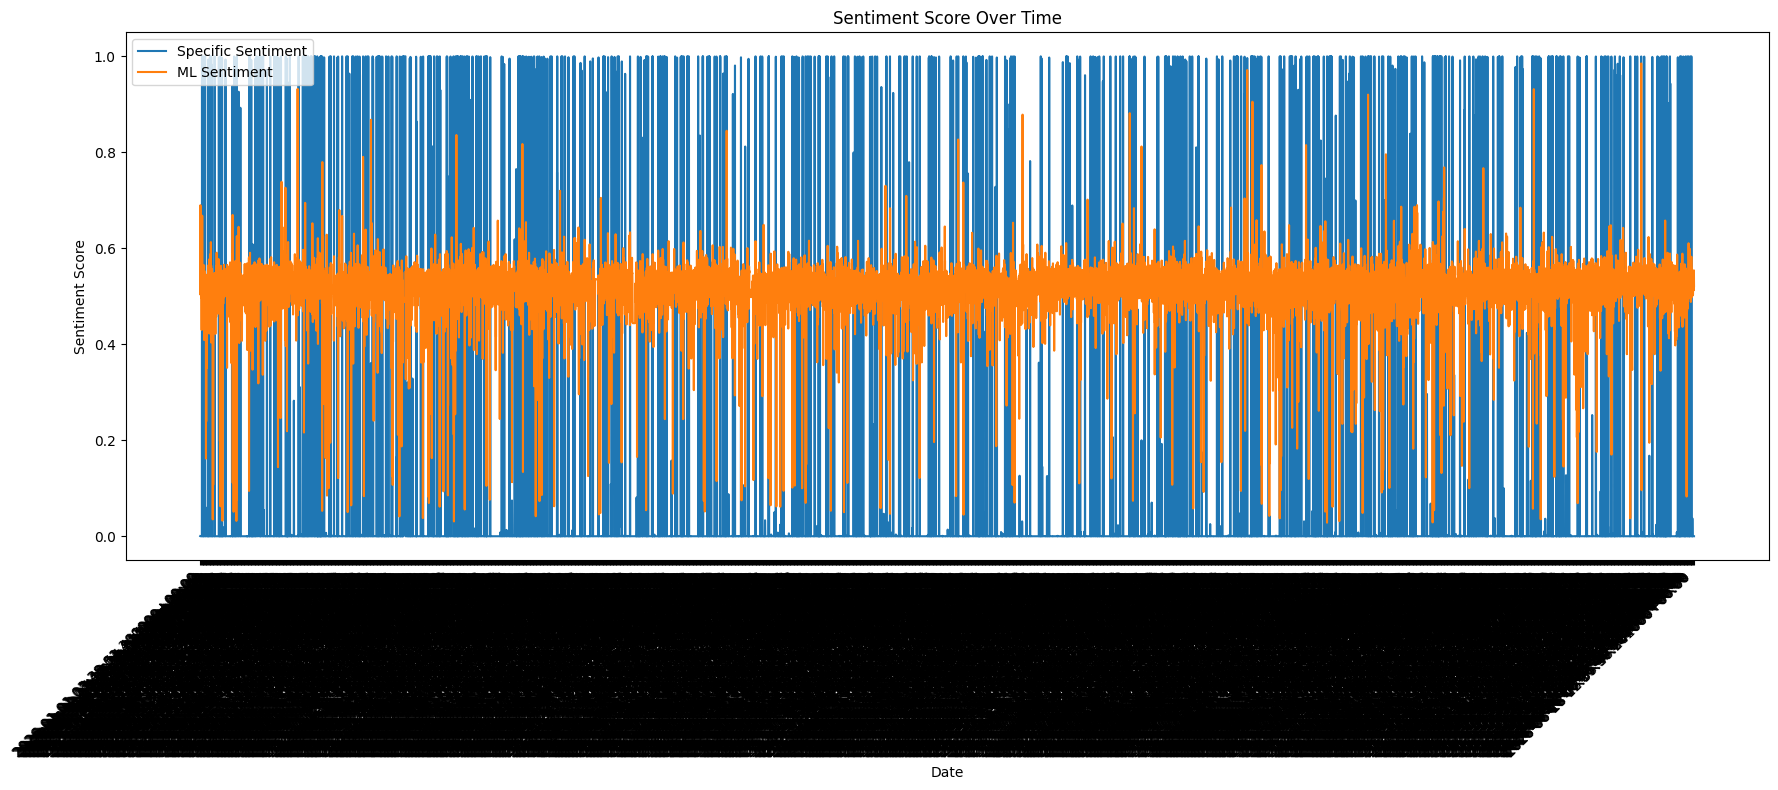

In [6]:
# normalizzo i createdAt in modo che conti solo il giorno e non anche l'ora
df["date_only"] = df["created_at"].str.split("T").str[0].replace("2026-", "")

# raggruppo per giorno e prendo la media del sentiment score
daily_sentiment_spec = df.groupby("date_only")["sent_italiano_score"].mean().reset_index()
daily_sentiment_gen = df.groupby("date_only")["sent_multilingua_v2_score"].mean().reset_index()

# plotto il sentiment nel tempo
plt.figure(figsize=(18, 8))

sns.lineplot(data=daily_sentiment_spec, x="date_only", y="sent_italiano_score", label="Specific Sentiment")
sns.lineplot(data=daily_sentiment_gen, x="date_only", y="sent_multilingua_v2_score", label="ML Sentiment")

plt.title("Sentiment Score Over Time")
plt.xlabel("Date")
plt.ylabel("Sentiment Score")
plt.xticks(rotation=45, ha="right")

# show fewer date labels to make them readable
step = 7
ax = plt.gca()
ax.set_xticks(ax.get_xticks()[::step])

plt.tight_layout()
plt.show()

In [9]:
# conto i sentiments
print(df["sentiment_multilingua_v2"].value_counts().reset_index())
print(df["sentiment_italiano"].value_counts().reset_index())

  sentiment_multilingua_v2  count
0                  neutral  10725
1                 positive   2002
2                 negative    738
  sentiment_italiano  count
0           negative  12642
1           positive    806
2            neutral     17


### 3. Distribuzione e Confronto Statistico degli Score

Generiamo gli istogrammi di densità (KDE) degli score e i box plot comparativi per visualizzare la distribuzione delle predizioni e il bias intrinseco dei modelli.

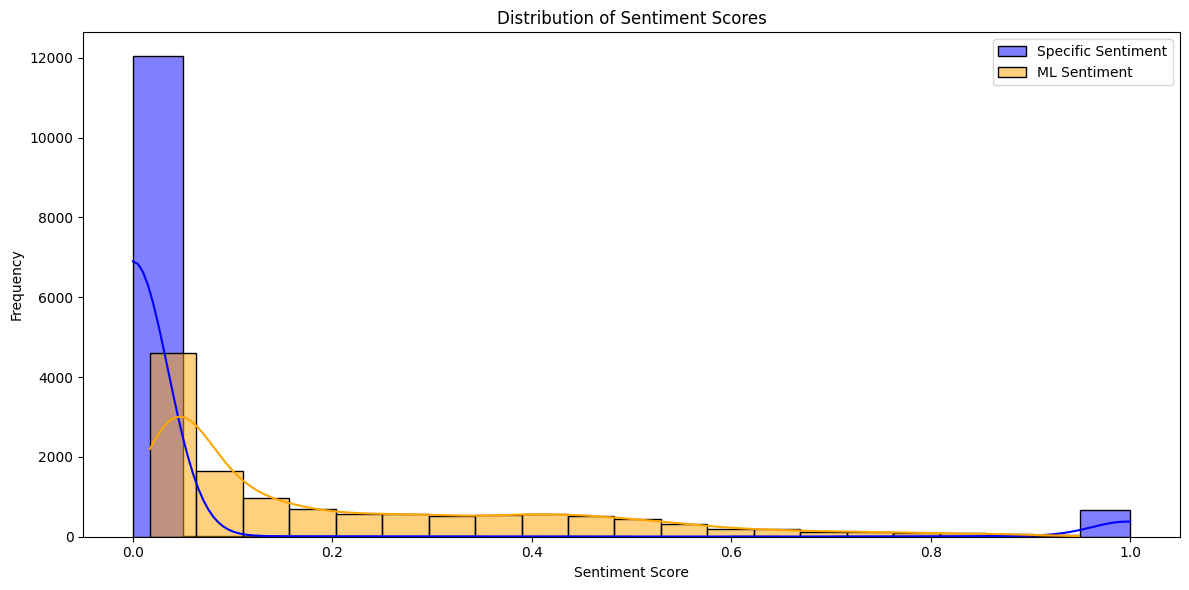

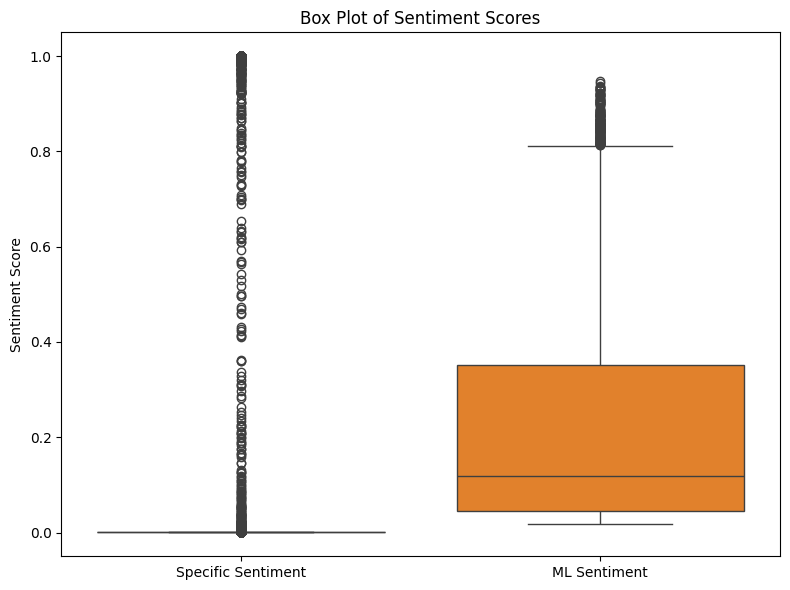

In [ ]:
# plotto la distribuzione dei sentiment
plt.figure(figsize=(12, 6))
sns.histplot(df["sent_spec_score"], bins=20, kde=True, color="blue", label="Specific Sentiment")
sns.histplot(df["sent_ml_score"], bins=20, kde=True, color="orange", label="ML Sentiment")
plt.title("Distribution of Sentiment Scores")
plt.xlabel("Sentiment Score")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()

# box plot per confrontare i due sentiment
plt.figure(figsize=(8, 6))
sns.boxplot(data=df[["sent_spec_score", "sent_ml_score"]])
plt.title("Box Plot of Sentiment Scores")
plt.ylabel("Sentiment Score")
plt.xticks([0, 1], ["Specific Sentiment", "ML Sentiment"])
plt.tight_layout()


### 4. WordCloud dei Post con Sentiment Negativo (per le slide)

Generiamo una visualizzazione WordCloud delle parole più ricorrenti all'interno dei post classificati con sentiment negativo dal modello multilingua, escludendo le stopword di NLTK (italiane e inglesi) per evidenziare i temi e i termini più caldi associati alle critiche.

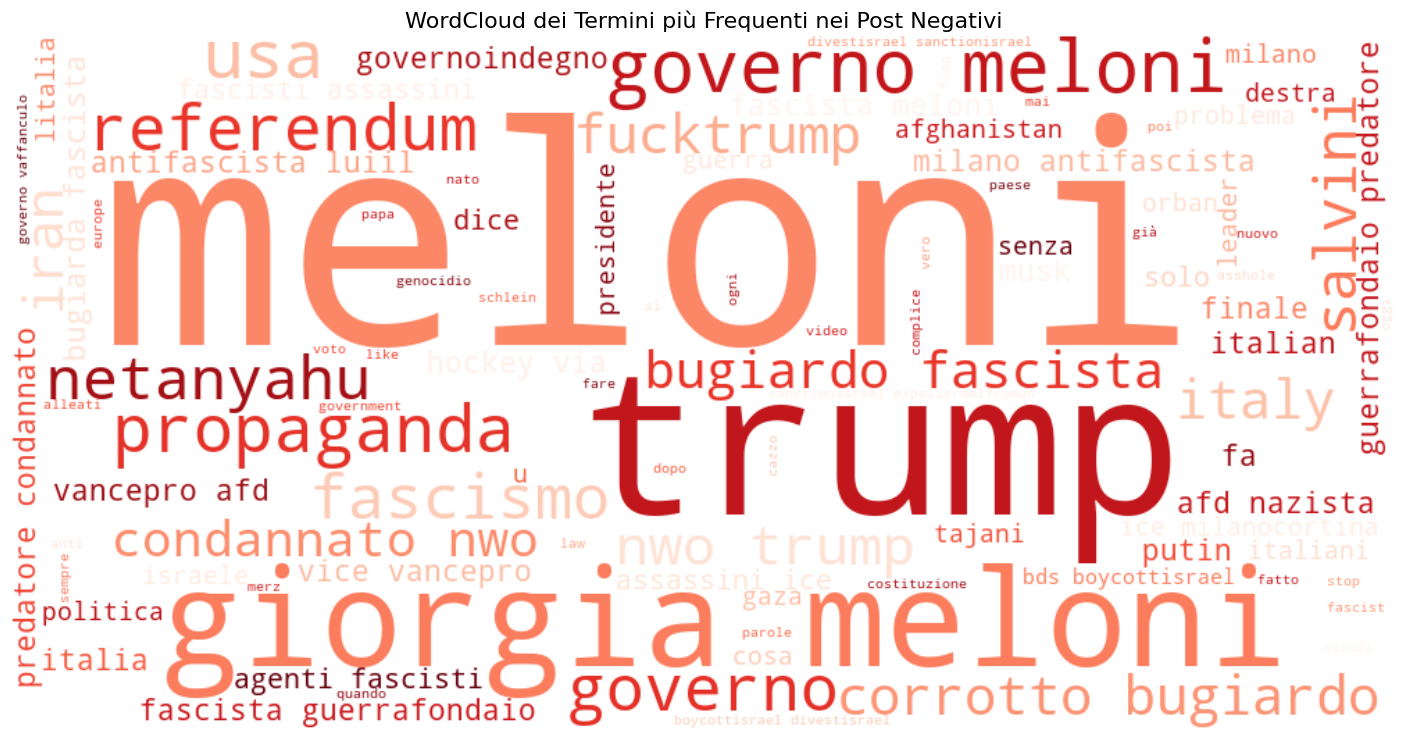

In [8]:
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
import matplotlib.pyplot as plt

nltk.download('stopwords', quiet=True)
stop_words_totali = set(stopwords.words('italian') + stopwords.words('english'))

# filtr i post negativi per il modello multilingua
df_neg = df[df["sentiment_multilingua_v2"] == "negative"]
text_neg = " ".join(df_neg["text_clean"].fillna("").astype(str).tolist())

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    stopwords=stop_words_totali,
    colormap='Reds_r',
    max_words=100,
    random_state=42
).generate(text_neg)

plt.figure(figsize=(15, 7.5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("WordCloud dei Termini più Frequenti nei Post Negativi", fontsize=16)
plt.tight_layout()
plt.show()
